In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import ensemble
from sklearn import metrics

In [3]:
import joblib

# 1.Učitavanje i priprema podataka

In [4]:
data = pd.read_csv('../data/online_shoppers_intention.csv')

In [5]:
data.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [6]:
data = pd.get_dummies(data, columns=['Month', 'VisitorType'], drop_first=True)

In [7]:
data['Revenue'] = data['Revenue'].astype(int)
data['Weekend'] = data['Weekend'].astype(int)

In [8]:
x = data.drop(['Revenue'], axis=1)
y = data['Revenue']

In [9]:
x.shape

(12330, 26)

In [10]:
y.shape

(12330,)

In [11]:
feature_names = x.columns
number_of_features = feature_names.shape[0]
number_of_features

26

# 2. Podela podataka

In [12]:
x_train_validation, x_test, y_train_validation, y_test = model_selection.train_test_split(x,y, test_size=0.33, stratify=y, random_state=7)
x_train, x_validation, y_train, y_validation = model_selection.train_test_split(x_train_validation, y_train_validation, stratify=y_train_validation, train_size=0.8, random_state=7)

Podela na trening, validaciju i test izvršena je, kao i u prethnodnim slučajevima, uz korišćenje parametra stratify čime je očuvan približno isti odnos klasa u sva tri skupa, s obzirom na izraženu neuravnoteženost ciljne promenljive uočenu u prvoj svesci. 

In [13]:
x_train.shape

(6608, 26)

In [14]:
x_test.shape

(4069, 26)

In [15]:
x_validation.shape

(1653, 26)

Za razliku od logističke regresije, standardizacija atributa ovde nije neophodna, s obzirom da je Random forest neosetljiv na skalu ulaznih vrednosti, odnosno model sam bira pragove podele nezavisne od apsolutne veličine brojeva. 

# 3. Podešavanje parametara i izbor modela 

In [16]:
n_estimators_list = [100,200,300]
max_depth_list = [None, 3, 4, 5, 6, 7]
best_max_depth = None 

best_score = 0
results = np.zeros((len(n_estimators_list), len(max_depth_list)))

for i in range(len(n_estimators_list)):
    n_estimator = n_estimators_list[i]
    
    for j in range(len(max_depth_list)):
        max_depth = max_depth_list[j]
        model = ensemble.RandomForestClassifier(n_estimators=n_estimator, 
                                                max_depth=max_depth, 
                                                class_weight='balanced',
                                                random_state=7)

        model.fit(x_train, y_train)
        y_prob = model.predict_proba(x_validation)[:,1]
        score = metrics.roc_auc_score(y_validation, y_prob)
        results[i,j] = score

        if score > best_score:
            best_score = score
            best_n_estimator = n_estimator
            best_max_depth = max_depth

Za izbor hiperparametra korišćen je ROC-AUC na validacionom skupu, jer je ova mera otporna na neuravnoteženost, za razliku od accuracy-ja koji bi kod ovog odnosa klasa bio zavaravajući.

In [17]:
print('Najbolji n_estimators: ', best_n_estimator)
print('Najbolji max_depth: ', best_max_depth)
print('Najbolji ROC-AUC: ', best_score)

Najbolji n_estimators:  200
Najbolji max_depth:  None
Najbolji ROC-AUC:  0.9198449803149606


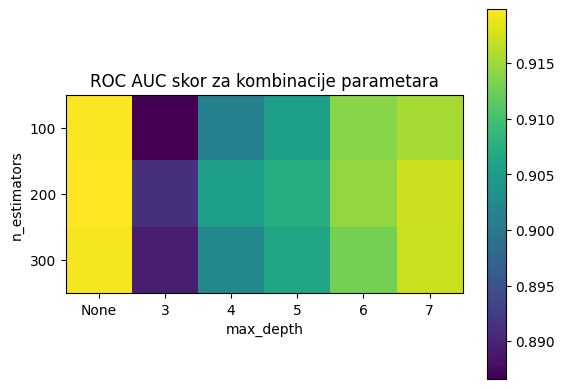

In [18]:
plt.imshow(results)

plt.xticks(range(len(max_depth_list)), [str(d) for d in max_depth_list])
plt.yticks(range(len(n_estimators_list)), n_estimators_list)
plt.xlabel('max_depth')
plt.ylabel('n_estimators')
plt.title('ROC AUC skor za kombinacije parametara')

plt.colorbar()
plt.show()

Grafik prikazuje ROC-AUC vrednosti dobijene na validacionom skupu za sve kombinacije parametara n_estimators i max_depth. Svetlije žute nijanse predstavljaju bolje, a tamnije ljubičaste lošije rezultate. 

Najizraženiji uticaj na performanse modela ima parametar max_depth=3 koji dosledno daje najniže ROC-AUC vrednosti za sve tri vrednosti n_estimators. Ovo ukazuje da je ograničenje dubine stabla na 3 nivoa prestrogo za ovaj problem.

Sa povećanjem dozvoljene dubine stabla, od 3 do 7, primetan je postepen i dosledan rast ROC-AUC vrednosti. Svaka naredna vrednost max_depth daje bolji rezulat od prethodne. Ovo ukazuje da model progresivno bolje hvata obrasce u podacima kako mu se dozvoljava veća dubina. 

Zanimljivo je da max_depth=7 ne dostiže performanse max_depth=None. Razlika je i dalje vidljiva na heatmapi, što sugeriše da model za ovaj problem ima koristi od stabala koja mogu da se granaju dublje od 7 nivoa.

Uticaj n_estimators je znatno manji u odnosu na max_depth. Razlike između redova unutar iste kolone su suptilne, dok su razlike između kolona veoma očigledne. 

Na osnovu heatmape najbolja kombinacija nalazi se u zoni gde je max_depth None ili 7, a n_estimators 200 ili 300. Ovo je u skladu sa ranije pronađenim optimalnim parametrima, tako da ova vizuelizacija dodatno potvrđuje da je izbor parametara bio opravdan. 

In [19]:
model = ensemble.RandomForestClassifier(n_estimators=best_n_estimator, max_depth=best_max_depth, class_weight='balanced', random_state=7)

In [20]:
model.fit(x_train_validation, y_train_validation)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=7)

Najbolja kombinacija n_estimators i max_depth je korišćena za treniranje finalnog modela na kombinovanom trening i validacionom skupu.  

# 4. Evaluacija finalnog modela

In [21]:
y_test_pred = model.predict(x_test)

In [22]:
print(metrics.confusion_matrix(y_test, y_test_pred))

[[3325  114]
 [ 309  321]]


In [23]:
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      3439
           1       0.74      0.51      0.60       630

    accuracy                           0.90      4069
   macro avg       0.83      0.74      0.77      4069
weighted avg       0.89      0.90      0.89      4069



In [24]:
metrics.accuracy_score(y_test, y_test_pred)

0.8960432538707299

In [25]:
metrics.precision_score(y_test, y_test_pred)

0.7379310344827587

In [26]:
metrics.recall_score(y_test, y_test_pred)

0.5095238095238095

In [27]:
metrics.f1_score(y_test, y_test_pred)

0.6028169014084508

Matrica konfuzije pokazuje 3325 tačno prepoznatih sesija bez kupovine i 321 tačno prepoznatu sesiju sa kupovinom, uz 114 lažno pozitivnih i 309 lažno negativnih predikcija. Ovo odgovara preciznosti od 74% i odzivu od 51%. 

In [28]:
metrics.roc_auc_score(y_test, model.predict_proba(x_test)[:,1])

0.9208693926344407

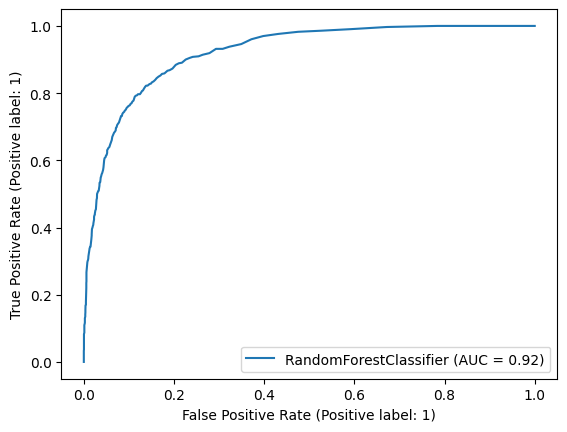

In [29]:
metrics.plot_roc_curve(model, x_test, y_test)

ROC AUC ne test skupu je gotovo identičan skoru dobijenom na validacionom skupu tokom podešavanja hiperparametara, što potvrđuje da model dobro generalizuje i da nije došlo do preprilagođavanja na trening podacima. 

# 5. Analiza važnosti atributa 

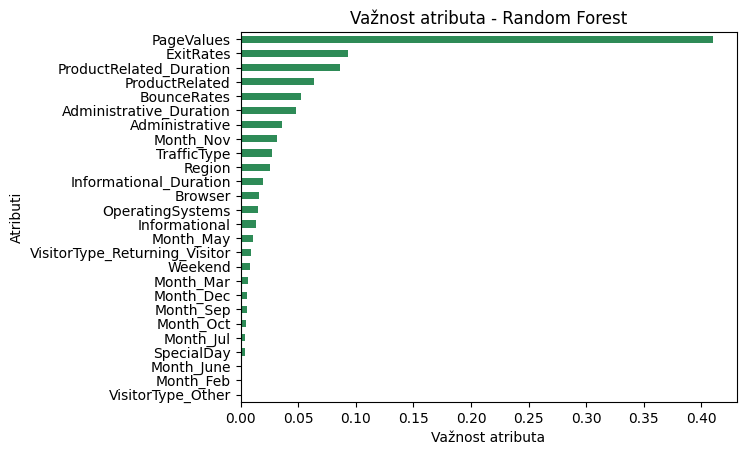

In [30]:
feature_importances = model.feature_importances_
importance = pd.Series(feature_importances, index = feature_names).sort_values()

importance.plot(kind='barh', color='seagreen')
plt.xlabel('Važnost atributa')
plt.ylabel('Atributi')
plt.title('Važnost atributa - Random Forest')
plt.show()

Grafik pokazuje da je PageValues ubedljivo najvažniji atribut za predviđanje kupovine. Ovaj zaključak je u skladu sa ranijom korelacionom analizom, za razliku od koeficijenta logističke regresije gde je ovaj atribut imao neočekivano slab uticaj. Ovo potvrđuje da je Random Forest dao mnogo pouzdaniju i intuitivniju procenu važnosti atributa. 

# 6. Čuvanje dobijenog modela

In [31]:
joblib.dump(model, '../models/03-RandomForest.pkl') 

['../models/03-RandomForest.pkl']

Ovi rezultati predstavljaju značajno poboljšanje u odnosu na model logističke regresije. Random Forest je ostvario bolji odziv uz zadržanu visoku preciznost, što ukazuje da bolje prepoznaje stvarne kupce. 

Model je pokazao dobru sposobnost generalizacije, s obzirom na to da je ROC-AUC na test skupu 0,921 gotovo identičan onom dobijenom na validacionom skupu tokom podešavanja hiperparametara, što isključuje mogućnost prekomernog prilagođavanja train podacima.  

Random Forest model je za razliku od logističke regresije, dao meru važnosti atributa koja je u potpunosti konzistentna sa početnom korelacionom analizom. 